In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'figure.titleweight' : 'bold',
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 09

## Exercise 09.1
### Assignment

Write a code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.



You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population with $M$ individuals, e.g. select the individual $j$ with the algorithm: $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Set the first city to always appear at position 1, so as to reduce the degeneration of the shortest route to be 2, which corresponds to walking the shortest route in clockwise and anti-clockwise directions.


Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.



Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bonds and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 34 cities randomly placed **on** a circumference
- 34 cities randomly placed **inside** a square

Show your results via:

-  a picture of  ${L^{(2)}}$  (or ${L^{(1)}}$ ) of the best path and of ${\langle L^{(2)}\rangle}$  (or ${\langle L^{(1)}\rangle}$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm
- a picture of the best path in cartesian coordinates


### Solution




### 1. Code Architecture: 

To solve the Traveling Salesperson Problem (TSP), i structured the genetic algorithm using three main classes:  **`CityMap`**, **`Individual`**, **`Population`**. 

#### 1.1 The `CityMap` Class
This class manages the coordinates and metrics of the TSP environment.
* **Attributes**: Stores the number of cities (`_N`), their $(x, y)$ coordinates in an $N \times 2$ matrix (`_coordinates`), and a symmetric $N \times N$ matrix for pair distances (`_distance_matrix`). The geometry (circle or square) is controlled by the `_map_type` flag.
* **Methods**: It handles the initialization of the environment (`load_cities` generates coordinates if a file is not already present) and computes the spatial distances (`length_eval` evaluates the total distance using $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$). It exposes read-only getters (`const`) to safely provide data to other classes.

#### 1.2 The `Individual` Class
This class represents a single candidate solution (a specific TSP route) in the population.
* **Attributes**: Contains the size of the problem (`N`), the specific sequence of visited cities stored as an Armadillo integer vector (`route`), and the total distance of this path (`length`), which acts as the fitness function. The first city is always fixed at index 0 to break cyclic degeneration.
* **Methods**: 
  * **Initialization & Evaluation**: The constructor generates a random, valid sequence of cities.
  In particular it creates a temporary ivec, and uses it to fill the first individual, and memorizes the indices still to use, in order to create a random path that visits only once each city.
    ```c++
    // Constructor
    Individual::Individual(const Parameters& params, Random& rnd, const CityMap& map)
        : N(params.n_cities), route(params.n_cities), length(-1.0) // Initialization: lenght = -1 because it hasn't been measured.
    {
        arma::ivec provv(N);
        for (int i = 0; i < N; i++) provv(i) = i;
        route(0) = 0;                       // 0-th cityt is fixed to eliminate cyclic deg
        for (int i = 1; i < N; i++) {       // Algorithm to generate a random route
            int j = int(rnd.Rannyu(i, N));
            route(i) = provv(j);
            provv(j) = provv(i);
        }
        this->length_eval(map); // Update length
    }
    ```
    `length_eval` computes the total route distance using the metrics provided by a `CityMap` object.

  * **Genetic Mutations**: Implements specific operators to explore the solution space:

    `swap_cities` (exchanges two random cities)
    I simply used the std::swap function. I generate two random index with a non-perfect method, but it should be a negligible cost. 
    ```c++
    void Individual::swap_cities(Random& _rnd, const CityMap& map) {
        
        // Random indices between 1 and N-1 (excluding the fixed 0-th city)
        int index_1 = int(_rnd.Rannyu(1, N));   
        int index_2;
        
        // Ensure the two selected indices are different
        do { 
            index_2 = int(_rnd.Rannyu(1, N)); 
        } while (index_2 == index_1);    

        std::swap(route(index_1), route(index_2));
        
        this->length_eval(map); 
    }

    ```
  
    `shift_cities` (translates a contiguous block of cities)
    I cut a block of cities of a random length in a random position and paste it on a random other position, further in the vector. To do these i use the `erase` and `insert` methods of the std class.

    ```c++
    void Individual::shift_cities(Random& _rnd, const CityMap& map) {
        // 1. Determine random parameters for the shift (excluding the fixed city)
        int n_to_shift = int(_rnd.Rannyu(1, N - 1));
        int starting_point = int(_rnd.Rannyu(1, N - n_to_shift + 1));
        int n_positions = int(_rnd.Rannyu(1, N - 1));

        // 2. Copy only the mobile cities (from index 1 to N-1) into a temporary vector
        std::vector<int> mobile_cities;
        for (int i = 1; i < N; i++) {
            mobile_cities.push_back(this->route(i));
        }
        
        // 3. Define iterators for the block boundaries
        auto first = mobile_cities.begin() + starting_point - 1;
        auto last = first + n_to_shift;
        
        // 4. Copy the block and remove it from the temporary vector
        std::vector<int> block(first, last);
        mobile_cities.erase(first, last);

        // 5. Calculate the new insertion position using modulo wrapping
        int new_insert_pos = (starting_point - 1 + n_positions) % mobile_cities.size();
        
        // 6. Paste the block back into the vector at the new calculated position
        mobile_cities.insert(mobile_cities.begin() + new_insert_pos, block.begin(), block.end());
        
        // 7. Reconnect the shifted cities back to the original route
        for (int i = 1; i < N; i++) {
            this->route(i) = mobile_cities[i - 1];
        }
        
        this->length_eval(map);
    }

    ```
    
    `reverse_cities` (inverts the order of a sub-sequence)
    This algorithm is specifically built for this type of problem, and it aims to untie a loop in the sequence, by inverting the order of its cities. The core algorithm is shown. 

    ```c++
    int half = (index_end - index_start) / 2 + ((index_end - index_start) % 2);

    // In-place reversal of the segment between index_start and index_end
        for (int i = 0; i < half; i++){
            std::swap(route(index_start + i), route(index_end - i));      // Swap the two cities in the route
        }
    ```
    
  * **Crossover**: The `execute_crossover` method combines the genetic information of two parent individuals to generate valid offspring, passing down exact sub-routes while filling the remaining slots based on the partner's sequence order.
    ```c++
    void Individual::execute_crossover(Individual& partner, Random& rnd, const CityMap& map) {
        // 1. Create two empty children routes
        Individual child_1(N);
        Individual child_2(N);

        // 2. Extract a random cut point between 1 and N-1
        int cut = int(rnd.Rannyu(1, N));

        // Boolean registries to track which cities have already been placed
        std::vector<bool> in_child_1(N, false);
        std::vector<bool> in_child_2(N, false);

        // PHASE 1: Copy exact sequence from parents up to the cut point
        for (int i = 0; i < cut; i++){
            child_1.route(i) = this->route(i);
            in_child_1[route(i)] = true;

            child_2.route(i) = partner.route(i);
            in_child_2[partner.route(i)] = true;
        }

        // PHASE 2: Fill the remaining slots maintaining the order of the other parent
        int index_c1 = cut; 
        int index_c2 = cut; 

        // Loop over all cities starting from 1
        for (int i = 1; i < this->N; i++) {

            // For Child 1: read from Parent 2 (partner)
            int city_from_p2 = partner.route(i);
            if (in_child_1[city_from_p2] == false) { // Se non c'è già...
                child_1.route(index_c1) = city_from_p2; // ...la inserisco
                index_c1++;                           // e vado avanti di un posto
            }

            // For Child 2: read from Parent 1 (this)
            int city_from_p1 = this->route(i);
            if (in_child_2[city_from_p1] == false) {
                child_2.route(index_c2) = city_from_p1;
                index_c2++;
            }
        }

        // Overwrite parents with the newly generated offspring
        this->route = child_1.route;
        partner.route = child_2.route;

        // Update lengths for both individuals
        this->length_eval(map);
        partner.length_eval(map);
    }
    ```

#### 1.3 The `Population` Class
This class acts as the orchestrator of the Genetic Algorithm, managing the evolutionary process of a group of `Individual` objects over consecutive generations.
* **Attributes**: It maintains the state of the evolution using two vectors of individuals (`_current_generation` and `_previous_generation`). It encapsulates the population size (`_n_indiv`), elitism threshold (`_n_best`), selection pressure (`_selection_exponent`), alongside crossover and mutation rates. It also holds a constant reference to the `CityMap` environment.
* **Methods**:
  * **Evolutionary Core**: It drives the evolutionary loop. The `selection` method picks the fittest parents, `crossover` mates them to create offspring, and various mutation methods (`mutation_1`, `mutation_2`, `mutation_3`) introduce genetic variance. Finally, `move_on_generations` transitions the newly formed offspring to be the parents of the next cycle.
  Here i report the selection method, to show that i used a function to compare the individuals length
  ```c++
    bool confronta(const Individual& a, const Individual& b) { 
        return a.get_length() < b.get_length(); 
    }

    void Population :: selection(Random& _rnd){
        // Order
        std::sort(_previous_generation.begin(), _previous_generation.end(), confronta); 

        // Elitism
        for (int i = 0; i < _n_best; i++){
            _current_generation[i] = _previous_generation[i];
        }

        // Rigged wheel
        for (int i = _n_best; i < _n_indiv; i++){
            int rigged_wheel = int(_n_indiv * pow(_rnd.Rannyu(), _selection_exponent));
            _current_generation[i] = _previous_generation[rigged_wheel];
        } 
    }
    ```
  * **Data Management & I/O**: Handles the initial setup (`initialize_population`) and safely logs the simulation's progress, tracking the best fitness trend over time (`print_best_legth`) and exporting the optimal final configuration (`print_best_route`).


I also use a class called `Parameters` to handle the instruction given to the code trought the text:
```text
N_CITIES        34
MAP_TYPE        1
N_INDIVIDUALS   1000
N_GENERATIONS   5000
MUTATION_RATE   0.2
CROSSOVER_RATE  0.7
SELECTION_EXPONENT   2
N_BEST_TO_SAVE  1
```

`MAP_TYPE`: 0 -> on circle, 1 -> in square

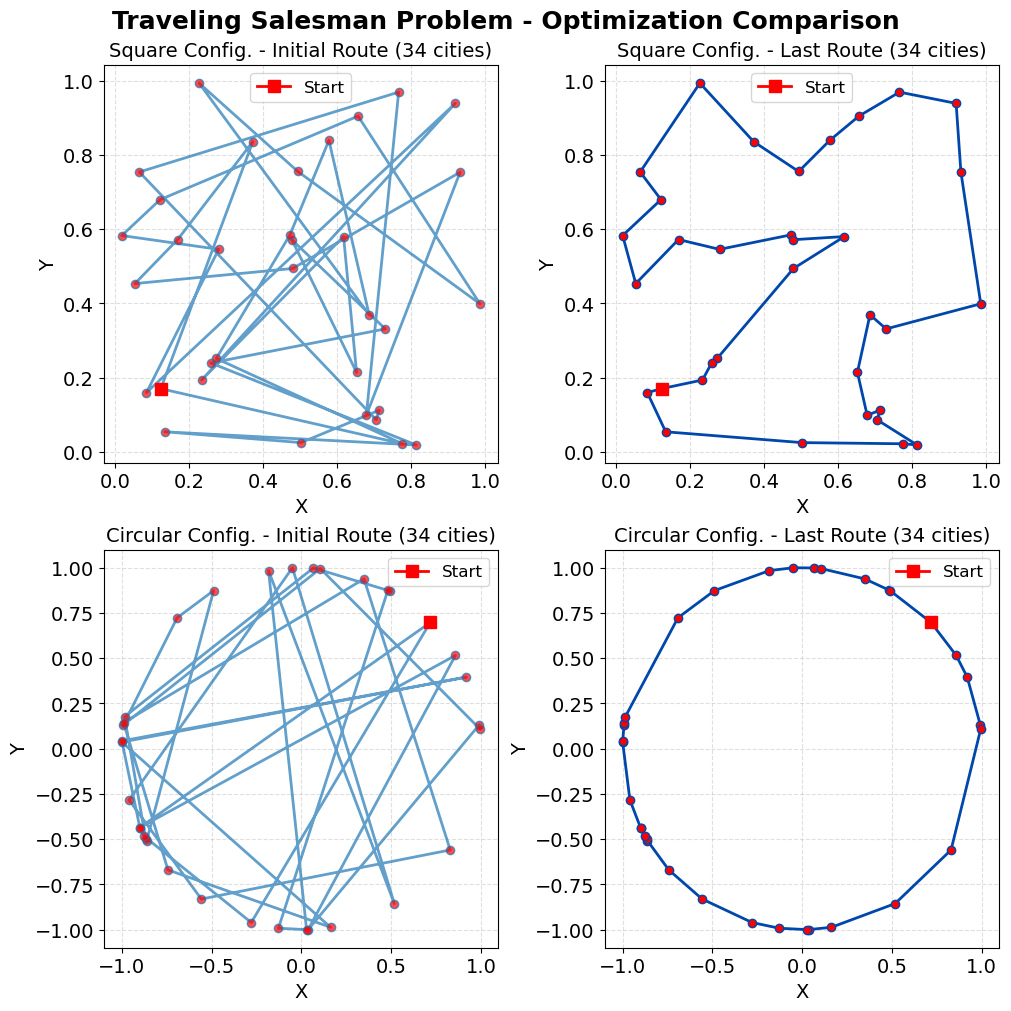

In [2]:
# Configuration Files
file_square = "OUTPUT_square/best_route_history.dat"
file_circle = "OUTPUT_circle/best_route_history.dat" 

# Helper Function for Data Extraction
def extract_routes(filename):
    """
    Reads the TSP history file and extracts the very first and the optimized last route.
    Returns: x_first, y_first, x_last, y_last, n_cities
    """
    with open(filename, 'r') as file:
        lines = file.readlines()
        n_cities = int(lines[2])

    # Load the entire history of routes
    x, y = np.loadtxt(filename, unpack=True, skiprows=3)

    # Extract and close the FIRST route
    x_first = x[0:n_cities]
    y_first = y[0:n_cities]
    x_first = np.append(x_first, x_first[0])
    y_first = np.append(y_first, y_first[0])

    # Extract and close the LAST route (optimized)
    x_last = x[-n_cities:]
    y_last = y[-n_cities:]
    x_last = np.append(x_last, x_last[0])
    y_last = np.append(y_last, y_last[0])

    return x_first, y_first, x_last, y_last, n_cities

# =============================================================================

# Extract data for the square distribution
x1_f, y1_f, x1_l, y1_l, n1 = extract_routes(file_square)

# Extract data for the circle distribution
x2_f, y2_f, x2_l, y2_l, n2 = extract_routes(file_circle)

# Plotting the Results (2x2 Grid)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), constrained_layout=True)

# ROW 1: Configuration inside a Square
# 1A: Initial Route
ax[0, 0].plot(x1_f, y1_f, marker='o', markerfacecolor=light_colors[1], linestyle='-', linewidth=2, markersize=6, color='tab:blue', alpha=0.7)
ax[0, 0].plot(x1_f[0], y1_f[0], marker='s', color='red', markersize=8, label='Start')
ax[0, 0].set_title(f"Square Config. - Initial Route ({n1} cities)", fontsize=14)
ax[0, 0].set_xlabel("X")
ax[0, 0].set_ylabel("Y")
ax[0, 0].legend()

# 1B: Optimized Route
ax[0, 1].plot(x1_l, y1_l, marker='o', linestyle='-', linewidth=2, markersize=6, markerfacecolor=light_colors[1],)
ax[0, 1].plot(x1_l[0], y1_l[0], marker='s', color='red', markersize=8, label='Start')
ax[0, 1].set_title(f"Square Config. - Last Route ({n1} cities)", fontsize=14)
ax[0, 1].set_xlabel("X")
ax[0, 1].set_ylabel("Y")
ax[0, 1].legend()

# ROW 2: Configuration on a Circle
# 2A: Initial Route
ax[1, 0].plot(x2_f, y2_f, marker='o',markerfacecolor=light_colors[1], linestyle='-', linewidth=2, markersize=6, color='tab:blue', alpha=0.7)
ax[1, 0].plot(x2_f[0], y2_f[0], marker='s', color='red', markersize=8, label='Start')
ax[1, 0].set_title(f"Circular Config. - Initial Route ({n2} cities)", fontsize=14)
ax[1, 0].set_xlabel("X")
ax[1, 0].set_ylabel("Y")
ax[1, 0].legend()

# 2B: Optimized Route
ax[1, 1].plot(x2_l, y2_l, marker='o', linestyle='-', linewidth=2, markersize=6, markerfacecolor=light_colors[1],)
ax[1, 1].plot(x2_l[0], y2_l[0], marker='s', color='red', markersize=8, label='Start')
ax[1, 1].set_title(f"Circular Config. - Last Route ({n2} cities)", fontsize=14)
ax[1, 1].set_xlabel("X")
ax[1, 1].set_ylabel("Y")
ax[1, 1].legend()

# General title for the entire figure
fig.suptitle("Traveling Salesman Problem - Optimization Comparison", fontsize=18, fontweight='bold')

# plt.savefig("tsp_optimization_comparison.png", dpi=300) 
plt.show()

Here are shown results contained in the folders `OUTPUT_square` and `OUTPUT_circle`, both containing a simulation executed with the following parameters:

    N_CITIES        34
    N_INDIVIDUALS   1000
    N_GENERATIONS   200
    MUTATION_RATE   0.4
    CROSSOVER_RATE  0.7
    SELECTION_EXPONENT   2
    N_BEST_TO_SAVE  1

- The number of generations and individual isn't very high, because the algorithm converges pretty fast to a good solution, from wich it hardly moves. 
- Mutation rate controls directly the probability of the 3 mutations that act on the individuals. Setting it at 0.4 is unusual, because it is very high and risks to damage the population. Indeed setting it that high worsen the best half length, as will be shown later, but I chose to do it because it worked pretty well anyway. This is probably due to the fact that I performed elitism on the best individual, leaving it untouched, and so I don't risk to lose it.
- The parameter CROSSOVER_RATE is the probability to execute crossover on an individual. It is high since it is the leading force of evolution: the goal is to get a better individual from the union of two good segments of the "parents".
- The paramenter SELECTION_EXPONENT is the weigth I use in the power law for the rigged wheel to select the individuals for the evolution. In particular I use the algorithm $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p = 2$ is the SELECTION_EXPONENT parameter. I chose this solution over the one that uses the lenght of individuals, because the last one seemed too "elitarian" to me, and I felt like first solution generated an offspring with more variety.
- The parameter N_BEST_TO_SAVE controls the number of individuals I perform elitism on. Setting it at more than 1 isn't very useful since I only need the best solution, and memorizing more than one would probably just occupy memory in vain



As it is shown in the images, the code performed well, and found in short time a solution that looks more or less good (it hasn't loops). Another hint that the algorithm performs well is shown from the solution of the test on circle configuration, that converged to the solution. 

Trovati 31 percorsi nel file. Generazione GIF in corso...
GIF salvata con successo come 'tsp_ottimizzazione_circle.gif'!
Trovati 31 percorsi nel file. Generazione GIF in corso...
GIF salvata con successo come 'tsp_ottimizzazione_square.gif'!


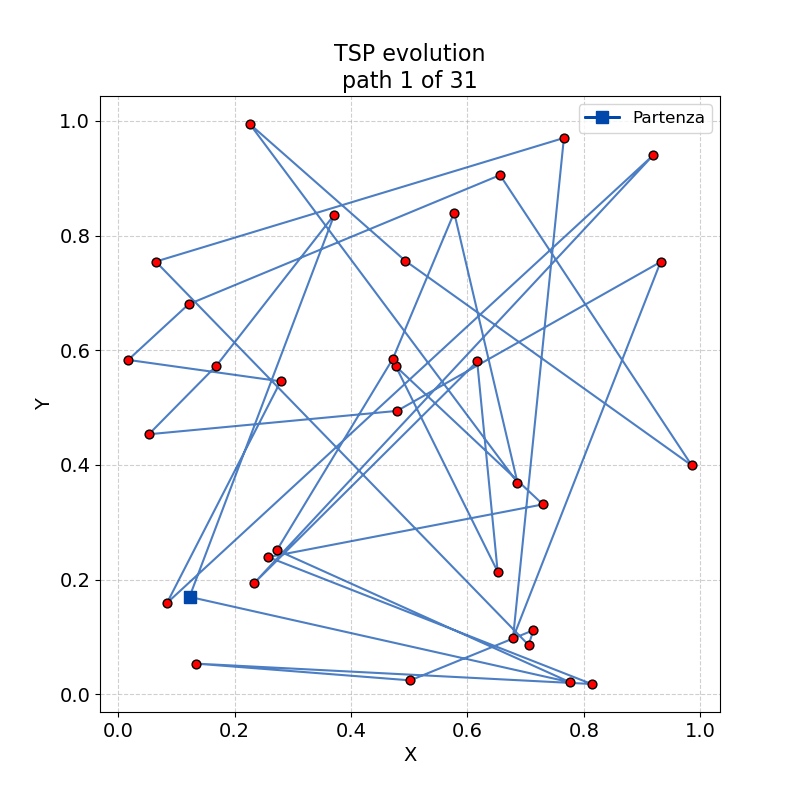

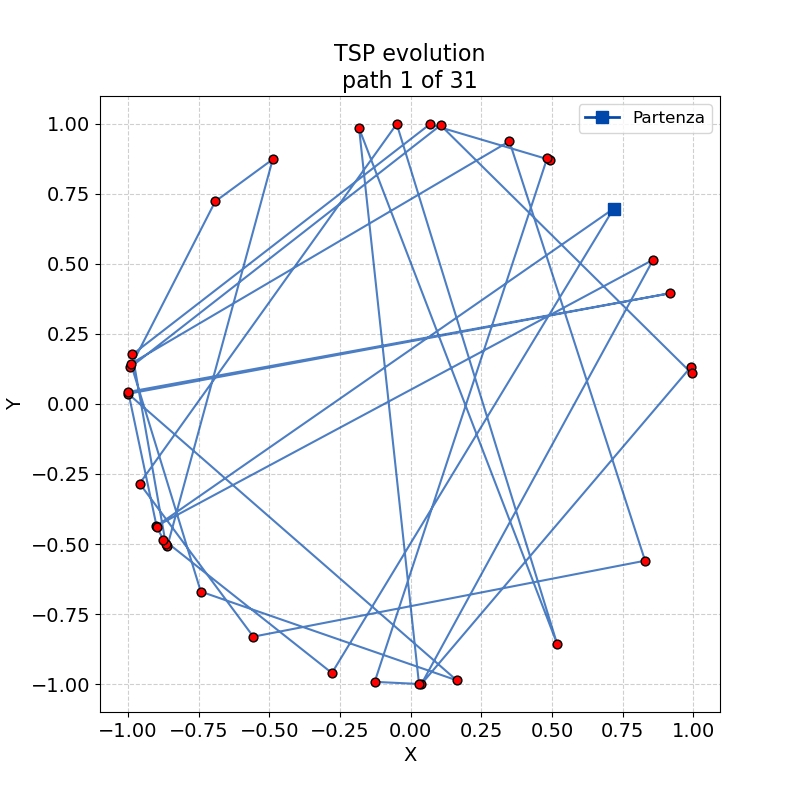

In [3]:
import matplotlib.animation as animation

def plot_tsp_evolution(filepath, gif_filename="tsp_evolution.gif", fps=10):
    routes = []
    current_route = []
    n_cities = 0

    # 1. LETTURA E PARSING DEL FILE
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        # Salto le righe vuote o i commenti
        if not line or line.startswith('#'):
            continue
        
        parts = line.split()
        
        # Se c'è un solo numero, è il numero di città (N)
        if len(parts) == 1:
            n_cities = int(parts[0])
            continue

        # Se ci sono due numeri, sono le coordinate X e Y
        if len(parts) == 2 and n_cities > 0:
            x, y = float(parts[0]), float(parts[1])
            current_route.append((x, y))

            # Se ho letto tutte le N città, il percorso è completo
            if len(current_route) == n_cities:
                # Aggiungo la prima città alla fine per "chiudere" l'anello nel grafico
                current_route.append(current_route[0]) 
                routes.append(np.array(current_route))
                current_route = [] # Resetto per il prossimo percorso

    if not routes:
        print("Nessun percorso valido trovato nel file.")
        return

    print(f"Trovati {len(routes)} percorsi nel file. Generazione GIF in corso...")

    # 2. SETUP DEL GRAFICO
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("Evoluzione del Commesso Viaggiatore")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle='--', alpha=0.6)

    # Disegno le città come puntini rossi (prendo le coordinate dal primo percorso)
    cities_x = routes[0][:, 0]
    cities_y = routes[0][:, 1]
    ax.scatter(cities_x, cities_y, c='red', zorder=5, s=40, edgecolors='black')
    
    # Evidenzio la città di partenza (indice 0) con un quadrato blu
    ax.plot(cities_x[0], cities_y[0], marker='s', color=light_colors[0], markersize=8, label="Partenza", zorder=6)
    ax.legend()

    # Creo un oggetto linea "vuoto" che aggiornerò in ogni frame
    line_obj, = ax.plot([], [], color=light_colors[0], linestyle='-', lw=1.5, alpha=0.7)

    # 3. FUNZIONI PER L'ANIMAZIONE
    def init():
        line_obj.set_data([], [])
        return line_obj,

    def update(frame):
        x = routes[frame][:, 0]
        y = routes[frame][:, 1]
        line_obj.set_data(x, y)
        ax.set_title(f"TSP evolution\npath {frame + 1} of {len(routes)}")
        return line_obj,

    # Creo l'animazione
    ani = animation.FuncAnimation(
        fig, update, frames=len(routes), 
        init_func=init, blit=True, interval=100
    )

    # 4. SALVATAGGIO
    # Usa 'pillow' come motore per salvare la GIF 
    ani.save(gif_filename, writer='pillow', fps=fps)
    print(f"GIF salvata con successo come '{gif_filename}'!")

    plt.close() # Chiude la figura per non intasare la memoria

# -------------------------------------------------------------

# Sostituisci con il percorso reale del tuo file
file_percorsi = "OUTPUT_circle/best_route_history.dat" 
plot_tsp_evolution(file_percorsi, gif_filename="tsp_ottimizzazione_circle.gif", fps=2)

file_percorsi = "OUTPUT_square/best_route_history.dat" 
plot_tsp_evolution(file_percorsi, gif_filename="tsp_ottimizzazione_square.gif", fps=2)

from IPython.display import Image, display
display(Image(filename="tsp_ottimizzazione_square.gif"))
display(Image(filename="tsp_ottimizzazione_circle.gif"))





To visualize better the evoulution I report here a gif of the algorithm working. I represent the first 10 generations of paths, and then 1 every 10 generations. It is interesting to see the attempts of the algorithm that after some time untie all the loops.

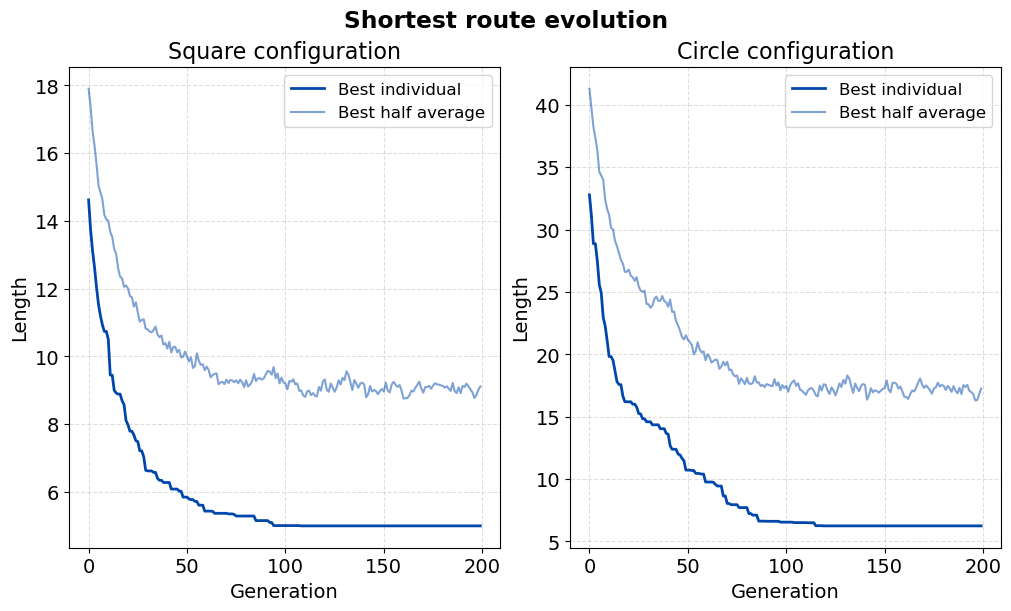

In [4]:
# Configuration File
file_square = ["OUTPUT_square/best_length_history.dat", "OUTPUT_square/half_length_history.dat"]
file_circle = ["OUTPUT_circle/best_length_history.dat", "OUTPUT_circle/half_length_history.dat"]
files = [file_square, file_circle]

fig, ax = plt.subplots(ncols=2, nrows=1, constrained_layout=True)
fig.suptitle('Shortest route evolution')

titles = ['Square configuration', 'Circle configuration']
labels = ['Best individual', 'Best half average']

for number, path in enumerate(files) : 

    best_length = np.loadtxt(path[0])
    half_length = np.loadtxt(path[1])

    ax[number].plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=labels[0]
            )

    ax[number].plot(half_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[0], alpha=0.5,
            linewidth=1.5,     # Spessore della linea
            label=labels[1]
            )

    ax[number].set_title(titles[number])

    ax[number].set_xlabel("Generation")
    ax[number].set_ylabel("Length")
    ax[number].legend(loc='best')

From the images it is possible to appreciate the fast convergence of the algorithm towards a near-optimal condition. To eliminate doubts about a better solution being found in more time, was performed also a simulation with 1000 generation, and the results confirm that, in this configuration, the algorithm only needs about 100 generation to get to a near-optimal solution. 

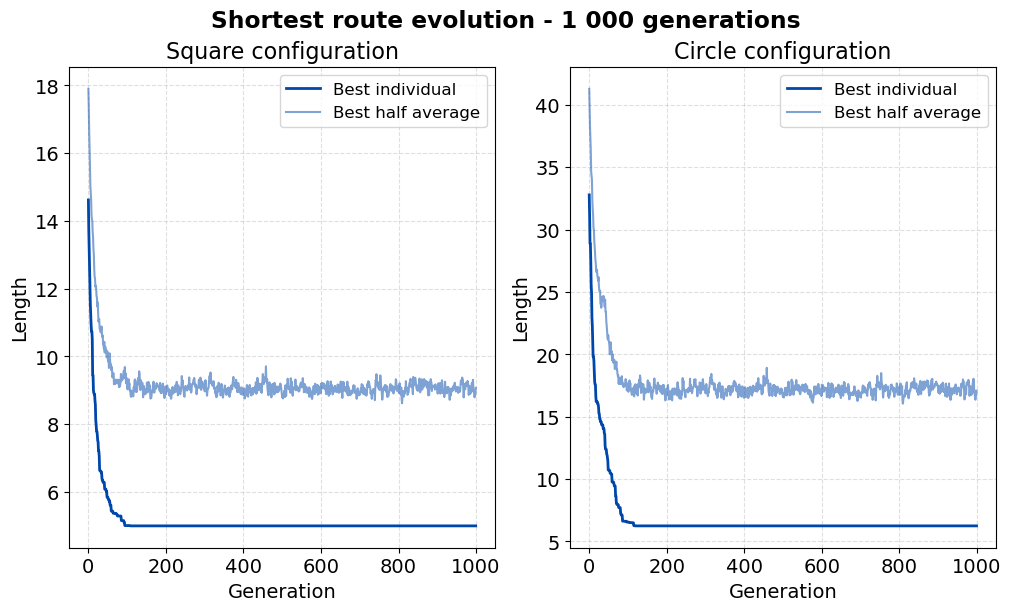

In [5]:
# Configuration File
file_square = ["OUTPUT_square_1k/best_length_history.dat", "OUTPUT_square_1k/half_length_history.dat"]
file_circle = ["OUTPUT_circle_1k/best_length_history.dat", "OUTPUT_circle_1k/half_length_history.dat"]
files = [file_square, file_circle]

fig, ax = plt.subplots(ncols=2, nrows=1, constrained_layout=True)
fig.suptitle('Shortest route evolution - 1 000 generations')

titles = ['Square configuration', 'Circle configuration']
labels = ['Best individual', 'Best half average']

for number, path in enumerate(files) : 

    best_length = np.loadtxt(path[0])
    half_length = np.loadtxt(path[1])

    ax[number].plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=labels[0]
            )

    ax[number].plot(half_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[0], alpha=0.5,
            linewidth=1.5,     # Spessore della linea
            label=labels[1]
            )

    ax[number].set_title(titles[number])

    ax[number].set_xlabel("Generation")
    ax[number].set_ylabel("Length")
    ax[number].legend(loc='best')



 The big difference between the best individual and the best half average is due to the high mutation rate. A brief exploration of the mutation parameter has been made, and the result are reported below.

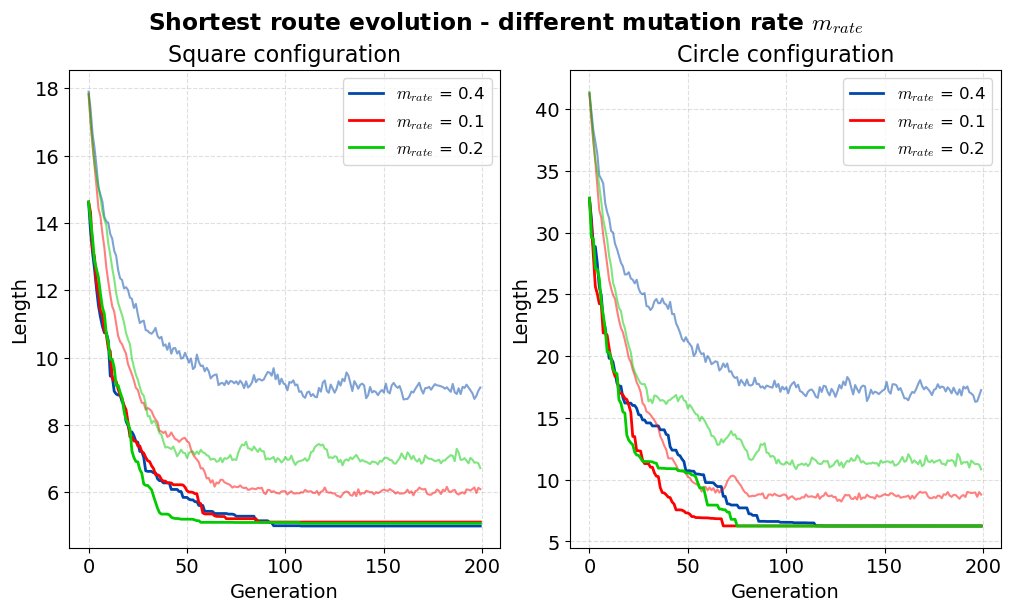

In [6]:
# Configuration File
file_square = ["OUTPUT_square/best_length_history.dat", "OUTPUT_square/half_length_history.dat"]
file_square_01 = ["OUTPUT_square_01/best_length_history.dat", "OUTPUT_square_01/half_length_history.dat"]
file_square_02 = ["OUTPUT_square_02/best_length_history.dat", "OUTPUT_square_02/half_length_history.dat"]
#file_square_06 = ["OUTPUT_square_06/best_length_history.dat", "OUTPUT_square_06/half_length_history.dat"]
file_circle = ["OUTPUT_circle/best_length_history.dat", "OUTPUT_circle/half_length_history.dat"]
file_circle_01 = ["OUTPUT_circle_01/best_length_history.dat", "OUTPUT_circle_01/half_length_history.dat"]
file_circle_02 = ["OUTPUT_circle_02/best_length_history.dat", "OUTPUT_circle_02/half_length_history.dat"]
#file_circle_06 = ["OUTPUT_circle_06/best_length_history.dat", "OUTPUT_circle_06/half_length_history.dat"]

files_square = [file_square, file_square_01, file_square_02] #, file_square_06]
files_circle = [file_circle, file_circle_01, file_circle_02] #, file_circle_06]

fig, ax = plt.subplots(ncols=2, nrows=1, constrained_layout=True)
fig.suptitle('Shortest route evolution - different mutation rate $m_{rate}$')

titles = ['Square configuration', 'Circle configuration']
labels = ['$m_{rate}$ = 0.4', '$m_{rate}$ = 0.1', '$m_{rate}$ = 0.2'] # , '$m_{rate}$ = 0.6']

# First sub
for number, path in enumerate(files_square) : 

    best_length = np.loadtxt(path[0])
    half_length = np.loadtxt(path[1])

    ax[0].plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number],
            label=labels[number]
            )

    ax[0].plot(half_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number], alpha=0.5,
            linewidth=1.5,     # Spessore della linea
            )

ax[0].set_title(titles[0])
ax[0].set_xlabel("Generation")
ax[0].set_ylabel("Length")
ax[0].legend(loc='best')

# Second sub
for number, path in enumerate(files_circle) : 

    best_length = np.loadtxt(path[0])
    half_length = np.loadtxt(path[1])

    ax[1].plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number],
            label=labels[number]
            )

    ax[1].plot(half_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number], alpha=0.5,
            linewidth=1.5,     # Spessore della linea
            )

ax[1].set_title(titles[1])
ax[1].set_xlabel("Generation")
ax[1].set_ylabel("Length")
ax[1].legend(loc='best')

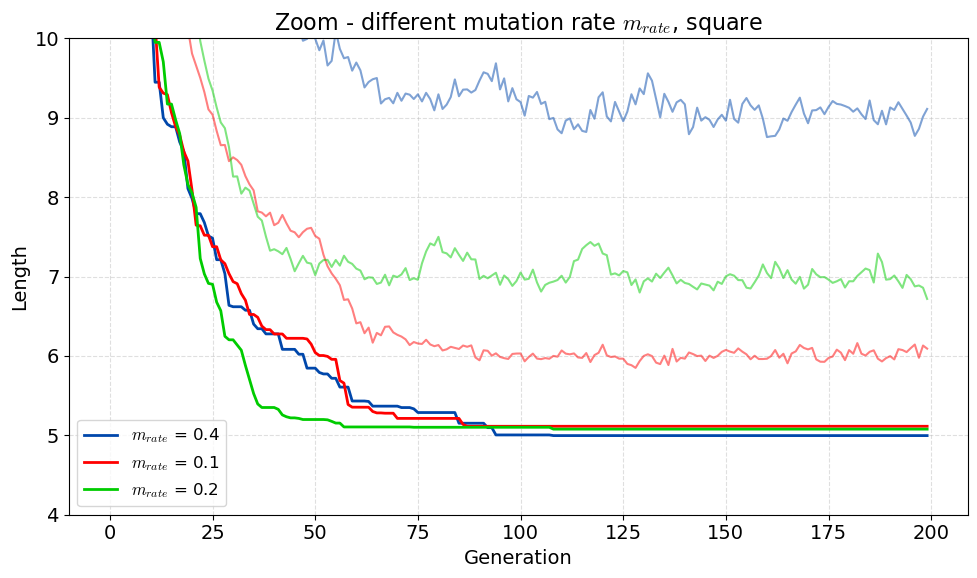

In [7]:
# Configuration File
file_square = ["OUTPUT_square/best_length_history.dat", "OUTPUT_square/half_length_history.dat"]
file_square_01 = ["OUTPUT_square_01/best_length_history.dat", "OUTPUT_square_01/half_length_history.dat"]
file_square_02 = ["OUTPUT_square_02/best_length_history.dat", "OUTPUT_square_02/half_length_history.dat"]

files_square = [file_square, file_square_01, file_square_02] #, file_square_06]

titles = ['Square configuration zoom', 'Circle configuration']
labels = ['$m_{rate}$ = 0.4', '$m_{rate}$ = 0.1', '$m_{rate}$ = 0.2'] # , '$m_{rate}$ = 0.6']

# First sub
for number, path in enumerate(files_square) : 

    best_length = np.loadtxt(path[0])
    half_length = np.loadtxt(path[1])

    plt.plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number],
            label=labels[number]
            )

    plt.plot(half_length, 
            linestyle='-',     # Unisce le città con una linea continua
            color=light_colors[number], alpha=0.5,
            linewidth=1.5,     # Spessore della linea
            )

plt.title('Zoom - different mutation rate $m_{rate}$')
plt.ylim(4, 10)
plt.title('Zoom - different mutation rate $m_{rate}$, square')
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')
plt.tight_layout()
plt.show()


As it is possible to appreciate form the zoomed image, other mutation rate choices would have been good. Actually, a smaller mutation rate, such as 0.1, 0.2 (more "canonical" ones), would have converged faster to their sub_optimal solution (about 60 generations for $m_{rate}$ = 0.2, 80 for $m_{rate}$ = 0.1). However it is appreciable form the plot that the mutation rate of 0.4 is the one that, in the end, gets the fittest solution, probably precisely for his high mutation rate.